# Quiz6 – Workout Data Visualization  
### Bibek Thapa

In this notebook, we will:

- Load the Workout Activity dataset  
- Create a scatterplot using multiple features  
- Represent 6–7 variables in a single visualization  
- Explain how each variable is mapped in the graphic  

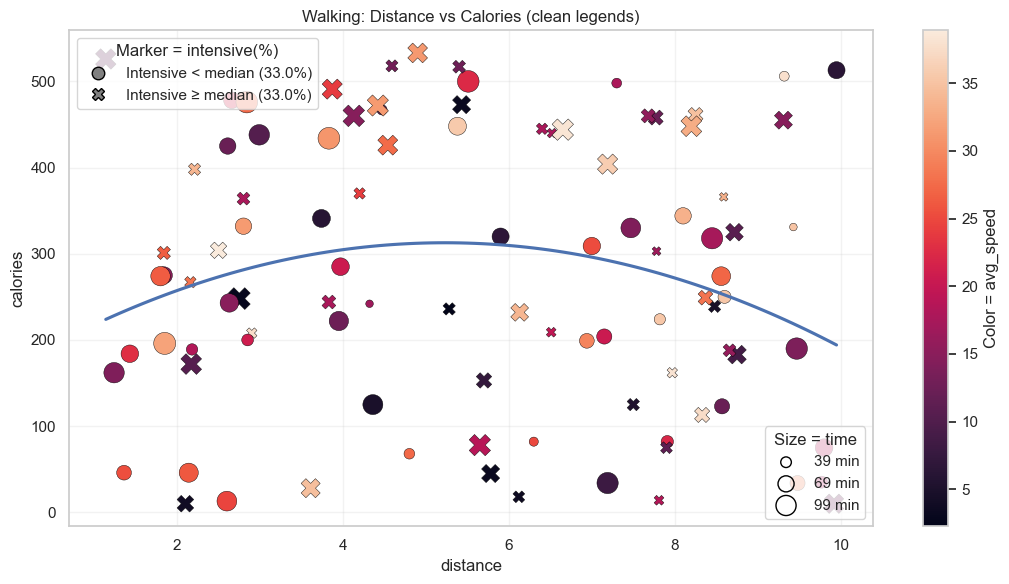

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(11, 6))

sc = sns.scatterplot(
    data=one,
    x="distance",
    y="calories",
    hue="avg_speed",
    size="time",
    style="intensive_group",
    sizes=(30, 250),
    palette="rocket",
    legend=False,
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(f"{WORKOUT_TYPE}: Distance vs Calories (clean legends)")
ax.set_xlabel("Distance")
ax.set_ylabel("Calories")
ax.grid(True, alpha=0.25)

# ---- 1) Colorbar for avg_speed ----
norm = plt.Normalize(one["avg_speed"].min(), one["avg_speed"].max())
sm = plt.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Color = avg_speed")

# ---- 2) Custom marker legend for intensive_group ----
marker_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               label=f"Intensive < median ({med_int:.1f}%)",
               markerfacecolor="gray", markeredgecolor="black", markersize=9),
    plt.Line2D([0],[0], marker="X", color="w",
               label=f"Intensive ≥ median ({med_int:.1f}%)",
               markerfacecolor="gray", markeredgecolor="black", markersize=9),
]
leg1 = ax.legend(handles=marker_handles, title="Marker = intensive(%)", loc="upper left")
ax.add_artist(leg1)

t_vals = np.quantile(one["time"].dropna(), [0.2, 0.5, 0.8]).astype(int)

tmin, tmax = one["time"].quantile([0.05, 0.95])
def time_to_size(t):
    t = np.clip(t, tmin, tmax)
    return 30 + (t - tmin) / (tmax - tmin + 1e-9) * 220

size_handles = [
    plt.scatter([], [], s=time_to_size(t), edgecolors="black", facecolors="none", label=f"{t} min")
    for t in t_vals
]
ax.legend(handles=size_handles, title="Size = time", loc="lower right")

# ---- 4) Regression line (overall trend) ----
sns.regplot(data=one, x="distance", y="calories", scatter=False, ci=False, order=2, ax=ax)

plt.tight_layout()
plt.show()

## So what is going on the above plot

This scatterplot shows the relationship between **Distance (x-axis)** and **Calories (y-axis)** for **Walking** workouts.  
Each point is one workout, but it also encodes extra information (so we’re seeing **6 variables** in one graphic):

- **Distance** → x-axis  
- **Calories** → y-axis  
- **Color = avg_speed** (see the colorbar on the right): lighter/brighter points mean **higher average speed**, darker points mean **lower speed**  
- **Size = time** (see the size legend): bigger circles mean the workout took **more minutes**  
- **Marker shape = intensive(%)** (see the marker legend): circles are **below the median intensity**, and X markers are **at or above the median intensity**  
- **Workout type = Walking** (this entire plot is filtered to one workout type to keep it readable)

So, instead of only comparing distance and calories, we can also see how **speed, duration, and intensity** relate to calories for walks of similar distance.

### Curved regression line (trend)
On top of the points, I added a **curved regression line** 
Unlike a straight line, this helps capture a **non-linear trend** for example, calories may increase faster at certain distances and flatten out at others.  
This line is not showing individual points. It is just a smooth overall pattern to help summarize the relationship between distance and calories.

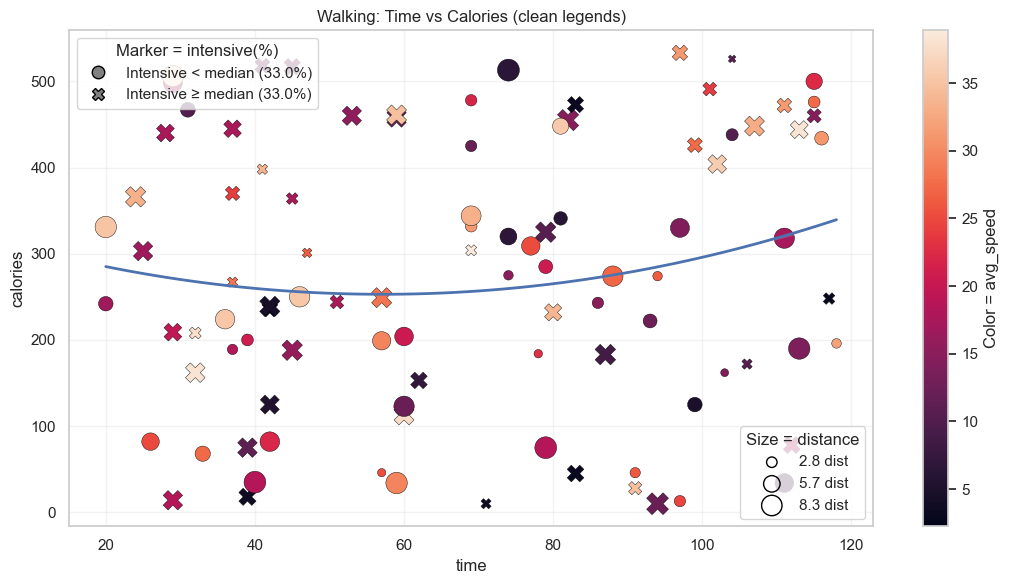

In [64]:
fig, ax = plt.subplots(figsize=(11, 6))

sns.scatterplot(
    data=one,
    x="time",
    y="calories",
    hue="avg_speed",           # color
    size="distance",           # size
    style="intensive_group",   # marker shape
    sizes=(30, 250),
    palette="rocket",
    legend=False,
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title(f"{WORKOUT_TYPE}: Time vs Calories (clean legends)")
ax.set_xlabel("Time (minutes)")
ax.set_ylabel("Calories")
ax.grid(True, alpha=0.25)

norm = plt.Normalize(one["avg_speed"].min(), one["avg_speed"].max())
sm = plt.cm.ScalarMappable(cmap="rocket", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Color = avg_speed")

marker_handles = [
    plt.Line2D([0],[0], marker="o", color="w",
               label=f"Intensive < median ({med_int:.1f}%)",
               markerfacecolor="gray", markeredgecolor="black", markersize=9),
    plt.Line2D([0],[0], marker="X", color="w",
               label=f"Intensive ≥ median ({med_int:.1f}%)",
               markerfacecolor="gray", markeredgecolor="black", markersize=9),
]
leg1 = ax.legend(handles=marker_handles, title="Marker = intensive(%)", loc="upper left")
ax.add_artist(leg1)

d_vals = np.quantile(one["distance"].dropna(), [0.2, 0.5, 0.8])

dmin, dmax = one["distance"].quantile([0.05, 0.95])
def dist_to_size(d):
    d = np.clip(d, dmin, dmax)
    return 30 + (d - dmin) / (dmax - dmin + 1e-9) * 220

size_handles = [
    plt.scatter([], [], s=dist_to_size(d), edgecolors="black", facecolors="none", label=f"{d:.1f} dist")
    for d in d_vals
]
ax.legend(handles=size_handles, title="Size = distance", loc="lower right")

sns.regplot(
    data=one,
    x="time",
    y="calories",
    scatter=False,
    ci=False,
    order=2,
    ax=ax,
    line_kws={"linewidth": 2}
)

plt.tight_layout()
plt.show()

## Time vs Calories (Walking only)

This scatterplot shows the relationship between **Time (x-axis)** and **Calories (y-axis)** for **Walking** workouts.  
Each point is one workout, and it also encodes extra information (so we’re still showing **6 variables** in one figure):

- **Time** → x-axis  
- **Calories** → y-axis  
- **Color = avg_speed** (colorbar): brighter colors mean **faster average speed**, darker colors mean **slower speed**  
- **Size = distance** (size legend): bigger points mean the workout covered **more distance**  
- **Marker shape = intensive(%)**: circles are **below the median intensity**, and X markers are **at or above the median**  
- **Workout type = Walking**: the plot is filtered to one workout type to keep it easy to read

### Curved regression line (trend)
The curve isn’t plotting new data points, it’s simply a smooth overall pattern that summarizes the relationship between the two variables.